In [2]:
#Importamos librerías esenciales para el trabajo con la base de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
#Cargamos el archivo csv que posee los datos a trabajar
df = pd.read_csv("data__movies.csv", sep=",")

In [4]:
#eliminamos variables que consideramos que no aportan a la greación de la regresión
df= df.drop(columns=["homepage", "status", "tagline", "title","original_title", "overview", "id"])

In [5]:
#Asumimos que la primera productora mencionada es la principal, por lo que todo elemento seguido 
#de la primera "," será eliminado.
df['production_companies'] = df['production_companies'].str.split(',').str[0]
#Estandarizamos los textos eliminando las mayúsculas, para que no tengamos posibles duplicados a futuro
df = df.map(lambda x: x.lower() if isinstance(x, str) else x)

In [6]:
#Rellenamos los datos faltantes para los géneros y productoras,
#en cambio con la fecha y duración eliminamos la fila
df["genres"] = df["genres"].fillna("desconocido")
df["production_companies"] = df["production_companies"].fillna("otros")
df = df.dropna(subset=["release_date", "runtime"])

In [7]:
#modificamos la columna de la fecha, para extraer el año y el mes de manera individual
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
df["anio"] = df["release_date"].dt.year.astype(int)
df["mes"] = df["release_date"].dt.month.astype(int)
df = df.drop(columns=["release_date"])

In [8]:
#Eliminamos registros con valores numéricos incoherentes (valores 0 o negativos)
df = df[(df["budget"] > 0) & (df["revenue"] > 0)
              & (df["runtime"] > 0) & (df["vote_count"] > 0)]


In [9]:
#Asumiendo que existe proridad en el orden de los géneros por importancia, solo nos quedamos con 
# el primer género de cada película
generos_exp = df["genres"].str.split(",").apply(
    lambda l: [g.strip() for g in l] if isinstance(l, list) else [])

In [10]:
#Generamos una lista con los géneros más citados respecticamente
top_generos = pd.Series([g for sub in generos_exp for g in sub]) \
                .value_counts().head(10).index.tolist()

In [11]:
#Usamos la siguinete función para eliminar espacios vacíos o comas, para evitar duplicados futuros 
def _limpiar(s):
    out = s
    for ch in [" ", ".", ",", "-", "(", ")", "/", "'", "&"]:
        out = out.replace(ch, "_")
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_")

In [12]:
#Indicamos el numero de géneros que posee cada pelícuka
for g in top_generos:
    df[f"gen_{_limpiar(g)}"] = generos_exp.apply(lambda lst: int(g in lst))
df["n_generos"] = generos_exp.apply(len)

In [13]:
#Nos quedamos con las productoras con mayor frencuencia.
prods_exp = df["production_companies"].str.split(",").apply(
    lambda l: [p.strip() for p in l] if isinstance(l, list) else [])
top_prods = pd.Series([p for sub in prods_exp for p in sub]) \
              .value_counts().head(10).index.tolist()
for p in top_prods:
    df[f"prod_{_limpiar(p)}"] = prods_exp.apply(lambda lst: int(p in lst))


In [14]:
#Nos quedamos con los idiomas con mayor frecnuencia.
top_lang = df["original_language"].value_counts().head(5).index
df["original_language"] = df["original_language"].where(
    df["original_language"].isin(top_lang), "other")

In [15]:
#Normalizamos los valor numéricos, para no tener rangos numéricos tan elevados
df["budget"]     = np.log(df["budget"])
df["revenue"] = np.log(df["revenue"])
df["popularity"] = np.log1p(df["popularity"])
df["vote_count"] = np.log1p(df["vote_count"])

In [16]:
#Eliminamos los valores más atípicos de la base de dstos, para no ensuciar la regresión
q_low  = df["revenue"].quantile(0.005)
q_high = df["revenue"].quantile(0.995)
df = df[(df["revenue"] >= q_low) & (df["revenue"] <= q_high)].copy()


In [17]:
#Restamos las medias de las siguinetes variables, 
for col in ["budget", "popularity", "vote_count",
            "vote_average", "runtime", "anio"]:
    df[col] = df[col] - df[col].mean()

In [18]:
#Reseteamos el conteo de filas del dataframe
df = df.reset_index(drop=True)

In [19]:
print(f"df_v2 final: {len(df):,} filas, {df.shape[1]} columnas")
print(f"Columnas creadas para géneros: {[c for c in df.columns if c.startswith('gen_')]}")
print(f"Columnas creadas para productoras: {[c for c in df.columns if c.startswith('prod_')]}")
df.head()

df_v2 final: 3,193 filas, 32 columnas
Columnas creadas para géneros: ['gen_drama', 'gen_comedy', 'gen_thriller', 'gen_action', 'gen_adventure', 'gen_romance', 'gen_crime', 'gen_science_fiction', 'gen_family', 'gen_fantasy']
Columnas creadas para productoras: ['prod_paramount_pictures', 'prod_universal_pictures', 'prod_columbia_pictures', 'prod_twentieth_century_fox_film_corporation', 'prod_new_line_cinema', 'prod_walt_disney_pictures', 'prod_village_roadshow_pictures', 'prod_miramax_films', 'prod_united_artists', 'prod_columbia_pictures_corporation']


,budget,genres,original_language,popularity,production_companies,revenue,runtime,vote_average,vote_count,anio,...,prod_paramount_pictures,prod_universal_pictures,prod_columbia_pictures,prod_twentieth_century_fox_film_corporation,prod_new_line_cinema,prod_walt_disney_pictures,prod_village_roadshow_pictures,prod_miramax_films,prod_united_artists,prod_columbia_pictures_corporation
0,2.684090,"adventure, fantasy, action",en,1.945155,walt disney pictures,20.683485,58.390229,0.589978,2.375647,5.349201,...,0,0,0,0,0,1,0,0,0,0
1,2.481565,"action, adventure, crime",en,1.688537,columbia pictures,20.596199,37.390229,-0.010022,2.368065,13.349201,...,0,0,1,0,0,0,0,0,0,0
2,2.540989,"action, adventure, science fiction",en,0.807962,walt disney pictures,19.464974,21.390229,-0.210022,1.625120,10.349201,...,0,0,0,0,0,1,0,0,0,0
3,2.533267,"fantasy, action, adventure",en,1.762528,columbia pictures,20.607711,28.390229,-0.410022,2.145872,5.349201,...,0,0,1,0,0,0,0,0,0,0
4,2.540989,"animation, family",en,0.908565,walt disney pictures,20.198671,-10.609771,1.089978,2.074620,8.349201,...,0,0,0,0,0,1,0,0,0,0


In [20]:
"Ejecutamos nuestra primera regresión"
formula_final = '''
revenue ~ vote_count + budget + anio
+ gen_family + gen_science_fiction + gen_crime + gen_fantasy + gen_romance + gen_drama
+ vote_average
+ prod_new_line_cinema + prod_twentieth_century_fox_film_corporation
+ prod_paramount_pictures + prod_universal_pictures + prod_columbia_pictures
+ prod_miramax_films + prod_village_roadshow_pictures
+ runtime
+ budget:gen_crime
+ budget:gen_science_fiction
+ budget:gen_romance
+ budget:gen_fantasy
+ budget:gen_thriller
+ budget:vote_average
+ budget:runtime
+ budget:prod_twentieth_century_fox_film_corporation
+ budget:prod_new_line_cinema
+ vote_average:popularity
+ popularity:vote_count
'''

modelo_final = smf.ols(formula_final, data=df).fit(cov_type="HC3")
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     191.8
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:52:28   Log-Likelihood:                -4652.1
No. Observations:                3193   AIC:                             9364.
Df Residuals:                    3163   BIC:                             9546.
Df Model:                          29                                         
Covariance Type:                  HC3                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [21]:
# 1. Obtenemos las métricas de influencia y los residuos estudentizados del modelo actual
influencia = modelo_final.get_influence()
residuos_estudentizados = influencia.resid_studentized_internal

# 2. Filtramos los valores atípicos severos, los cuales pueden estar afectando
#a la normalización de la regresión
df_limpio = df[abs(residuos_estudentizados) <= 2.0].copy()

modelo_corregido = smf.ols(formula_final, data=df_limpio).fit()

print(f"Observaciones eliminadas: {len(df) - len(df_limpio)}")
print(modelo_corregido.summary())

Observaciones eliminadas: 157
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     339.7
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:52:29   Log-Likelihood:                -3334.3
No. Observations:                3036   AIC:                             6729.
Df Residuals:                    3006   BIC:                             6909.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

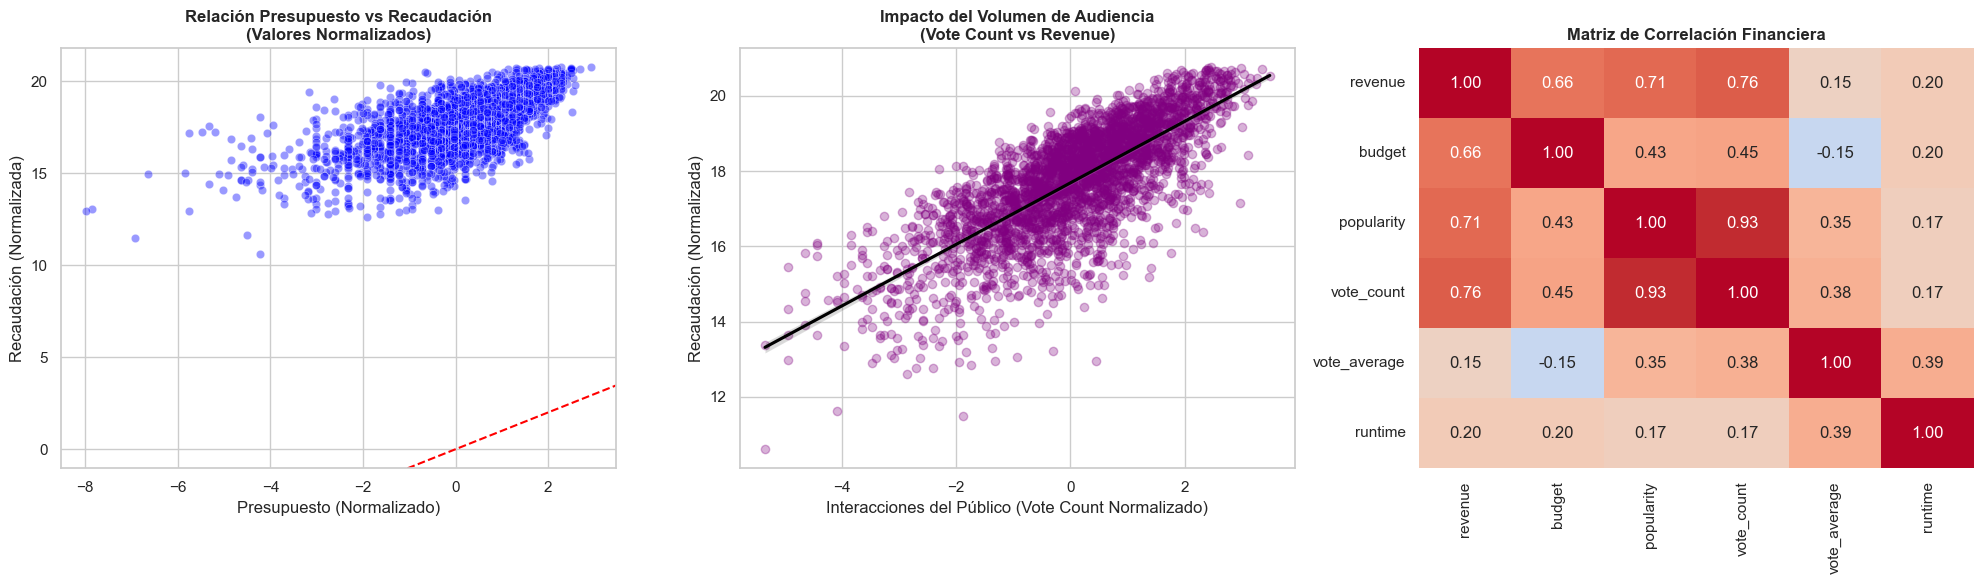

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual para la consultora
sns.set_theme(style="whitegrid", palette="muted")

# Creamos una figura con 3 subgráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -------------------------------------------------------------------------
# 1. Distribución de Ingresos (Revenue) vs Presupuesto (Budget)
# -------------------------------------------------------------------------
sns.scatterplot(
    data=df_limpio, 
    x="budget", 
    y="revenue", 
    alpha=0.4, 
    color="blue",
    ax=axes[0]
)
axes[0].set_title('Relación Presupuesto vs Recaudación\n(Valores Normalizados)', fontweight='bold')
axes[0].set_xlabel('Presupuesto (Normalizado)')
axes[0].set_ylabel('Recaudación (Normalizada)')
axes[0].axline((0, 0), slope=1, color="red", linestyle="--") # Línea de equilibrio de inversión

# -------------------------------------------------------------------------
# 2. El Efecto del "Hype": Interacciones vs Recaudación
# -------------------------------------------------------------------------
sns.regplot(
    data=df_limpio, 
    x="vote_count", 
    y="revenue",
    scatter_kws={'alpha':0.3, 'color':'purple'},
    line_kws={'color': 'black'},
    ax=axes[1]
)
axes[1].set_title('Impacto del Volumen de Audiencia\n(Vote Count vs Revenue)', fontweight='bold')
axes[1].set_xlabel('Interacciones del Público (Vote Count Normalizado)')
axes[1].set_ylabel('Recaudación (Normalizada)')

# -------------------------------------------------------------------------
# 3. Matriz de Correlación de Variables Financieras Clave
# -------------------------------------------------------------------------
# Seleccionamos solo las métricas cuantitativas clave
vars_financieras = ['revenue', 'budget', 'popularity', 'vote_count', 'vote_average', 'runtime']
corr_matrix = df_limpio[vars_financieras].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    vmin=-1, vmax=1, 
    cbar=False,
    ax=axes[2]
)
axes[2].set_title('Matriz de Correlación Financiera', fontweight='bold')

plt.tight_layout()
plt.show()

--- Descripción Estadística de las Variables ---
           revenue       budget   vote_count   popularity  vote_average  \
count  3036.000000  3036.000000  3036.000000  3036.000000   3036.000000   
mean     17.742646     0.093971     0.066560     0.040073      0.005657   
std       1.501088     1.328992     1.390844     0.897975      0.850970   
min      10.610094    -7.981538    -5.343260    -2.965630     -3.310022   
25%      16.804428    -0.534786    -0.748141    -0.495221     -0.510022   
50%      17.912940     0.312512     0.178199     0.103531     -0.010022   
75%      18.829693     1.023358     1.035590     0.661825      0.589978   
max      20.767966     2.920478     3.492605     3.589436      2.189978   

           runtime  
count  3036.000000  
mean      0.221256  
std      20.257440  
min     -69.609771  
25%     -13.609771  
50%      -3.609771  
75%      10.390229  
max     137.390229  


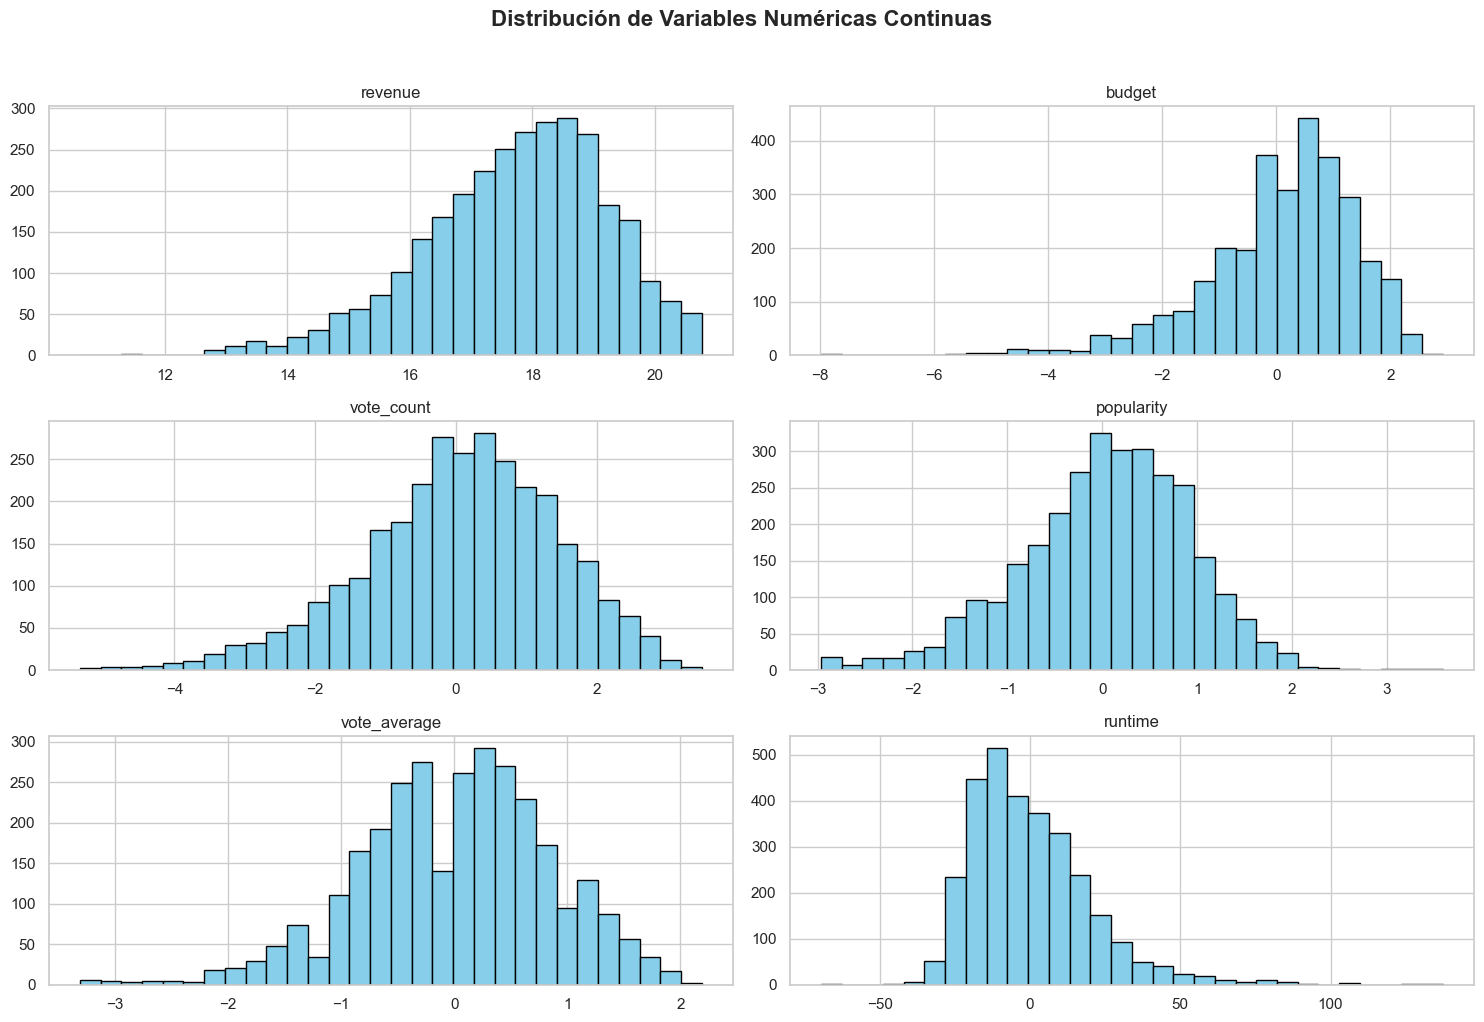

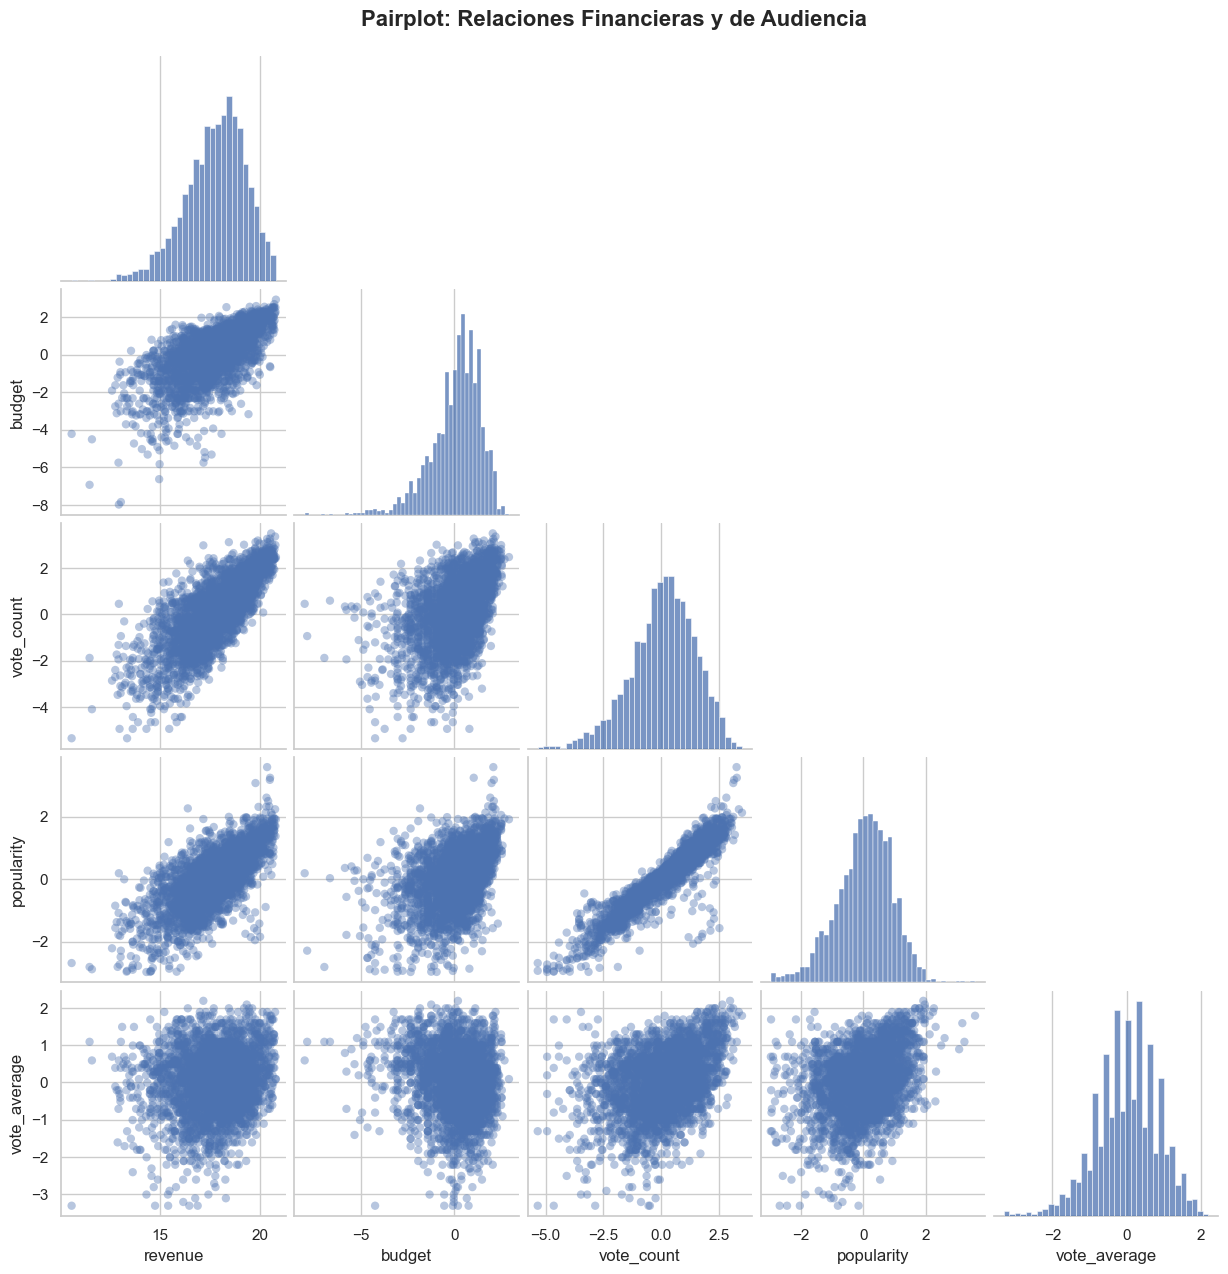

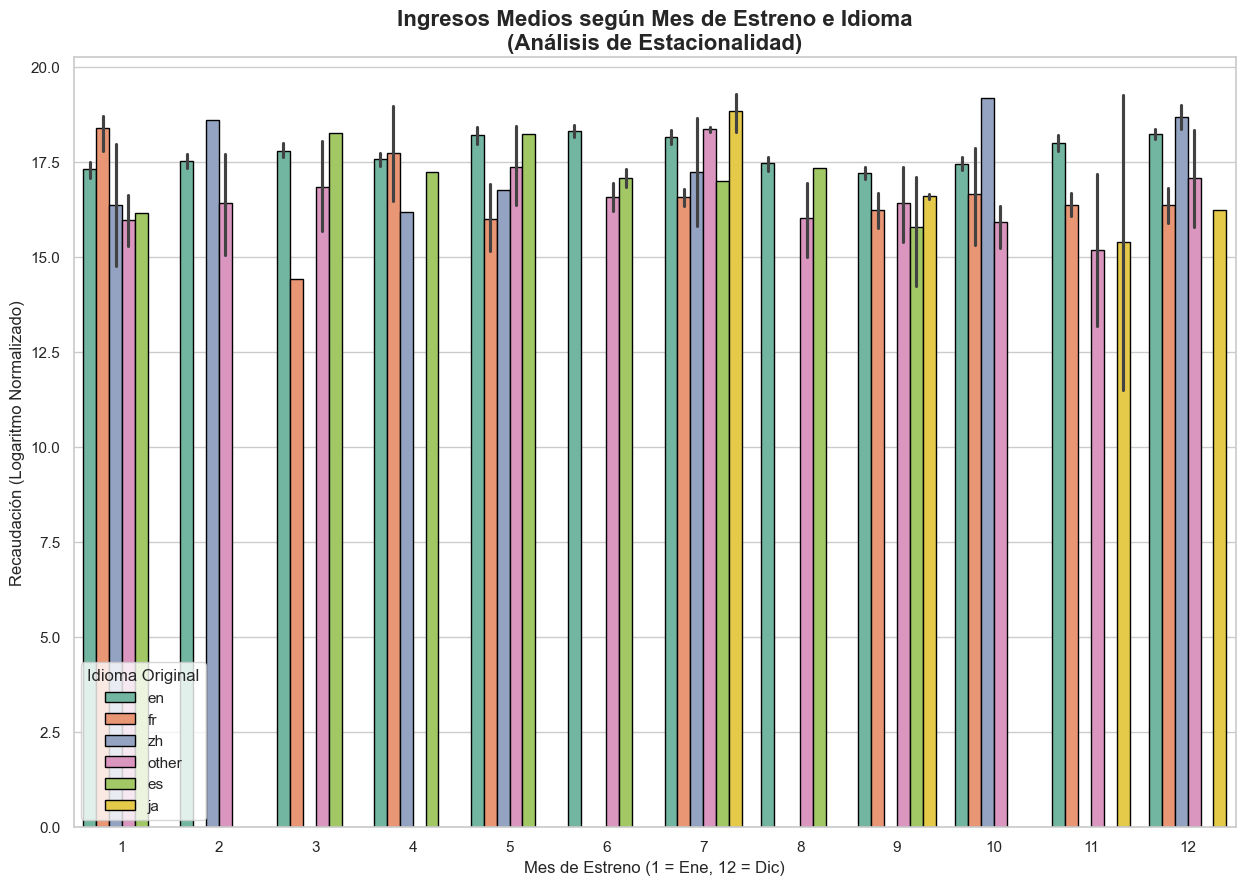

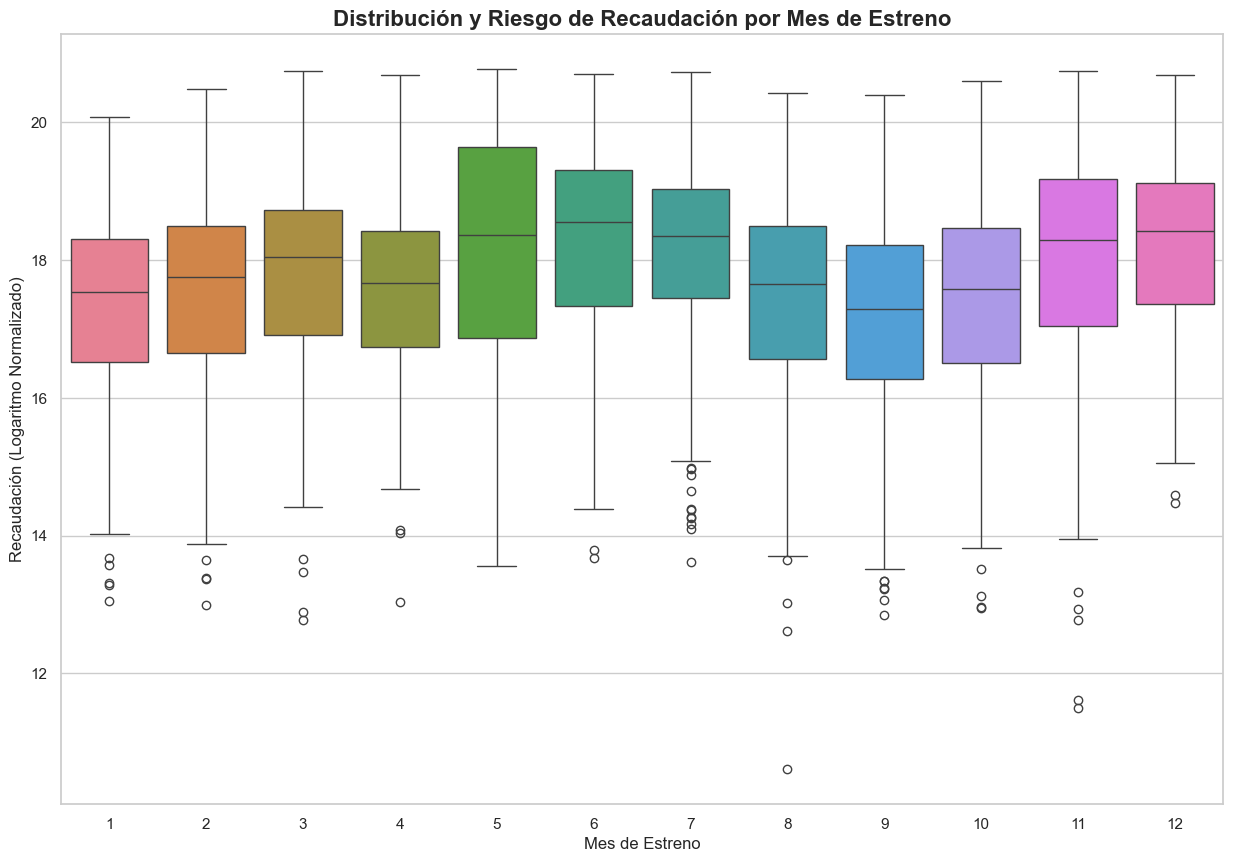

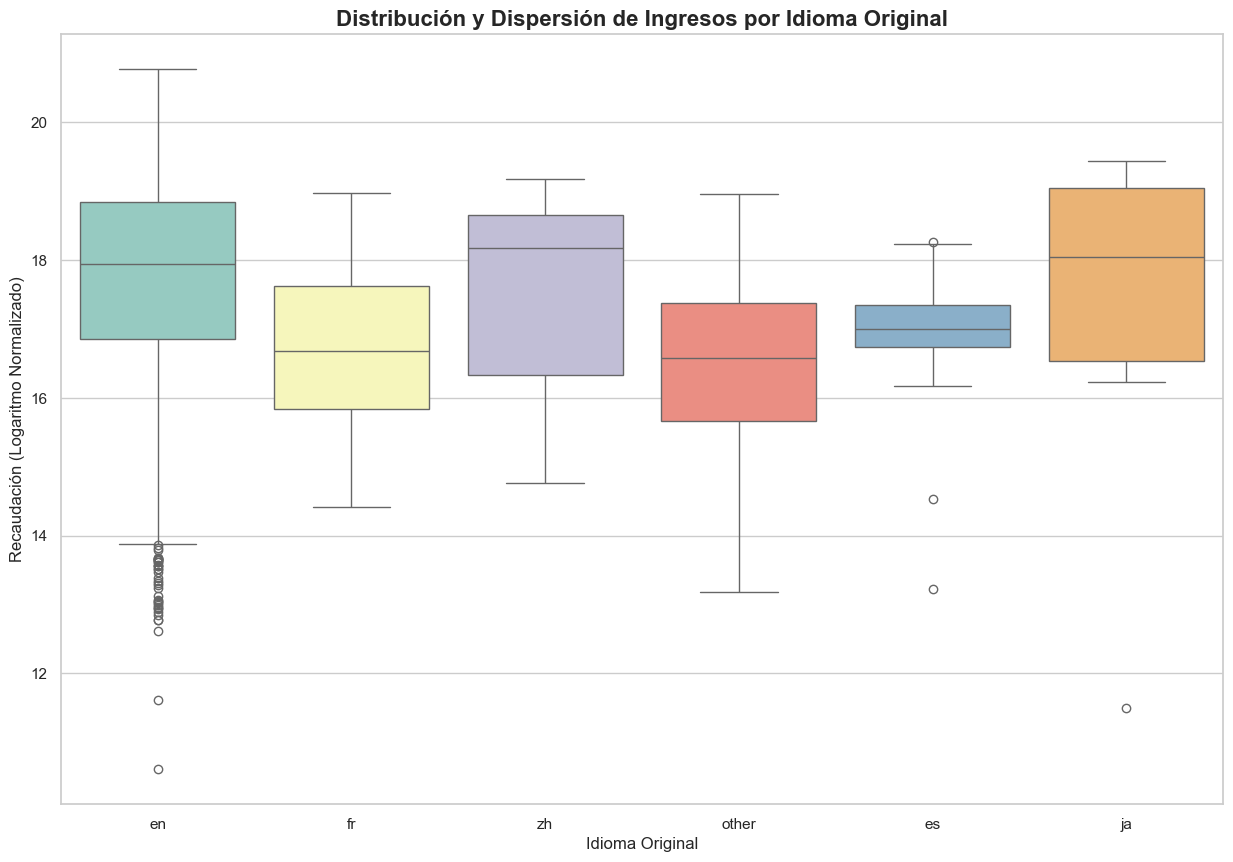

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración de estilo global
sns.set_theme(style="whitegrid")

# 1. Descripción estadística de las variables clave
print("--- Descripción Estadística de las Variables ---")
columnas_desc = ['revenue', 'budget', 'vote_count', 'popularity', 'vote_average', 'runtime']
descripcion = df_limpio[columnas_desc].describe()
print(descripcion)

# 2. Histogramas (Distribución de las variables financieras y métricas)
df_limpio[columnas_desc].hist(figsize=(15, 10), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribución de Variables Numéricas Continuas", fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Pairplot (Gráfico de pares para ver correlaciones múltiples)
# Usamos un subconjunto de variables clave para que el gráfico sea legible y útil
sns.pairplot(
    df_limpio[['revenue', 'budget', 'vote_count', 'popularity', 'vote_average']], 
    corner=True, # Solo muestra la mitad inferior para no duplicar info
    plot_kws={'alpha': 0.4, 'edgecolor': 'none'} # Puntos semi-transparentes para ver densidad
)
plt.suptitle("Pairplot: Relaciones Financieras y de Audiencia", fontsize=16, y=1.02, fontweight='bold')
plt.show()

# 4. Barplot: Recaudación media según Mes y color (hue) por Idioma
plt.figure(figsize=(15, 10))
sns.barplot(
    data=df_limpio,
    x="mes",
    y="revenue",
    hue="original_language",
    palette="Set2",
    edgecolor="black"
)
plt.title("Ingresos Medios según Mes de Estreno e Idioma\n(Análisis de Estacionalidad)", fontsize=16, fontweight='bold')
plt.xlabel("Mes de Estreno (1 = Ene, 12 = Dic)", fontsize=12)
plt.ylabel("Recaudación (Logaritmo Normalizado)", fontsize=12)
plt.legend(title="Idioma Original")
plt.show()

# 5. Boxplot: Rango de recaudación según el Mes (Análisis de Riesgo)
plt.figure(figsize=(15, 10))
sns.boxplot(
    data=df_limpio,
    x="mes",
    y="revenue",
    hue="mes",
    palette=sns.color_palette("husl", df_limpio["mes"].nunique()),
    legend=False
)
plt.title("Distribución y Riesgo de Recaudación por Mes de Estreno", fontsize=16, fontweight='bold')
plt.xlabel("Mes de Estreno", fontsize=12)
plt.ylabel("Recaudación (Logaritmo Normalizado)", fontsize=12)
plt.show()

# 6. Boxplot: Rango de recaudación según el Idioma Original
plt.figure(figsize=(15, 10))
sns.boxplot(
    data=df_limpio,
    x="original_language",
    y="revenue",
    hue="original_language",
    palette=sns.color_palette("Set3", df_limpio["original_language"].nunique()),
    legend=False
)
plt.title("Distribución y Dispersión de Ingresos por Idioma Original", fontsize=16, fontweight='bold')
plt.xlabel("Idioma Original", fontsize=12)
plt.ylabel("Recaudación (Logaritmo Normalizado)", fontsize=12)
plt.show()

C:\Users\Familia\AppData\Local\Temp\ipykernel_4568\2031074014.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=coefs_generos, y=generos, palette=colores_gen)


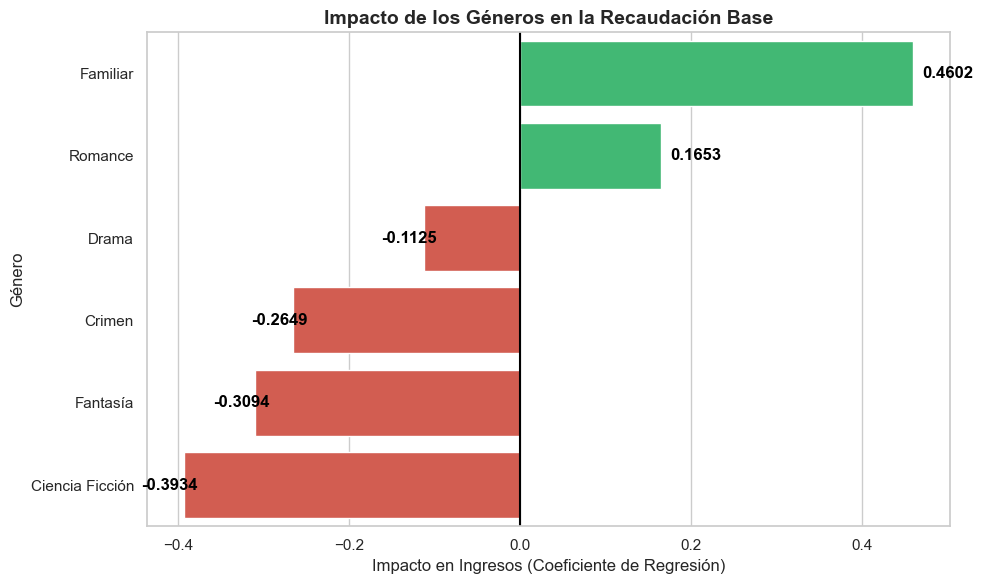

C:\Users\Familia\AppData\Local\Temp\ipykernel_4568\2031074014.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=coefs_productoras, y=productoras, palette='Blues_d')


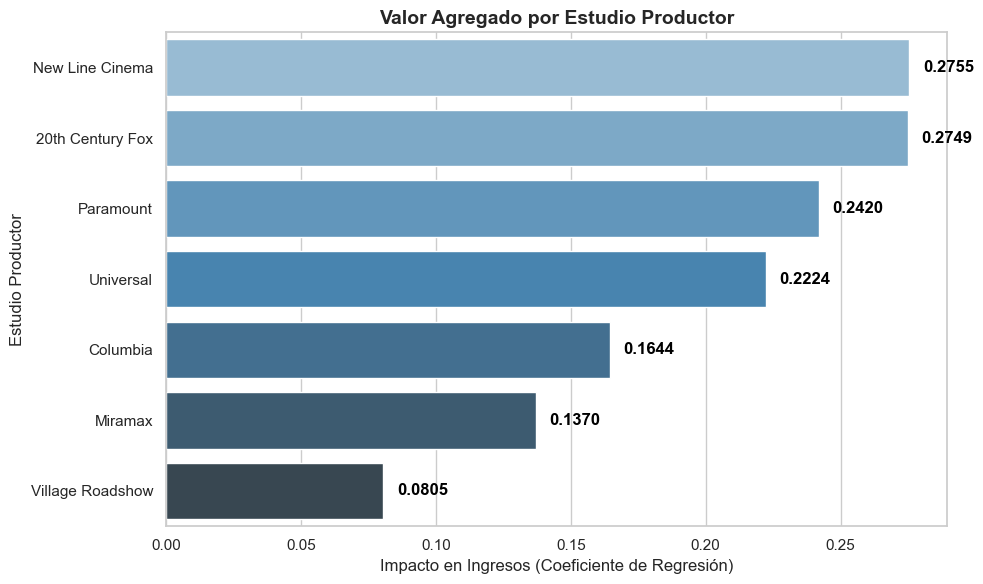

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Datos extraídos de los coeficientes del modelo de regresión final (R-squared: 0.766)
generos = ['Familiar', 'Romance', 'Drama', 'Crimen', 'Fantasía', 'Ciencia Ficción']
coefs_generos = [0.4602, 0.1653, -0.1125, -0.2649, -0.3094, -0.3934]

productoras = ['New Line Cinema', '20th Century Fox', 'Paramount', 'Universal', 'Columbia', 'Miramax', 'Village Roadshow']
coefs_productoras = [0.2755, 0.2749, 0.2420, 0.2224, 0.1644, 0.1370, 0.0805]

# Configuración de estilo global para la presentación
sns.set_theme(style="whitegrid")

# ==============================================================================
# GRÁFICO 1: Impacto de los Géneros en la Recaudación Base
# ==============================================================================
plt.figure(figsize=(10, 6))

# Definimos colores: Verde para impacto positivo, Rojo para impacto negativo
colores_gen = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefs_generos]

ax1 = sns.barplot(x=coefs_generos, y=generos, palette=colores_gen)
plt.title('Impacto de los Géneros en la Recaudación Base', fontsize=14, fontweight='bold')
plt.xlabel('Impacto en Ingresos (Coeficiente de Regresión)', fontsize=12)
plt.ylabel('Género', fontsize=12)

# Añadimos una línea en el 0 para separar claramente ganancias de pérdidas
plt.axvline(0, color='black', linewidth=1.5)

# Añadimos las etiquetas numéricas a cada barra
for i, v in enumerate(coefs_generos):
    # Ajustamos la posición del texto dependiendo si es positivo o negativo
    ax1.text(v + (0.01 if v > 0 else -0.05), i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 2: Valor Agregado por Estudio Productor
# ==============================================================================
plt.figure(figsize=(10, 6))

# Usamos una paleta de azules para mostrar confianza corporativa
ax2 = sns.barplot(x=coefs_productoras, y=productoras, palette='Blues_d')
plt.title('Valor Agregado por Estudio Productor', fontsize=14, fontweight='bold')
plt.xlabel('Impacto en Ingresos (Coeficiente de Regresión)', fontsize=12)
plt.ylabel('Estudio Productor', fontsize=12)

# Añadimos las etiquetas numéricas a cada barra
for i, v in enumerate(coefs_productoras):
    ax2.text(v + 0.005, i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

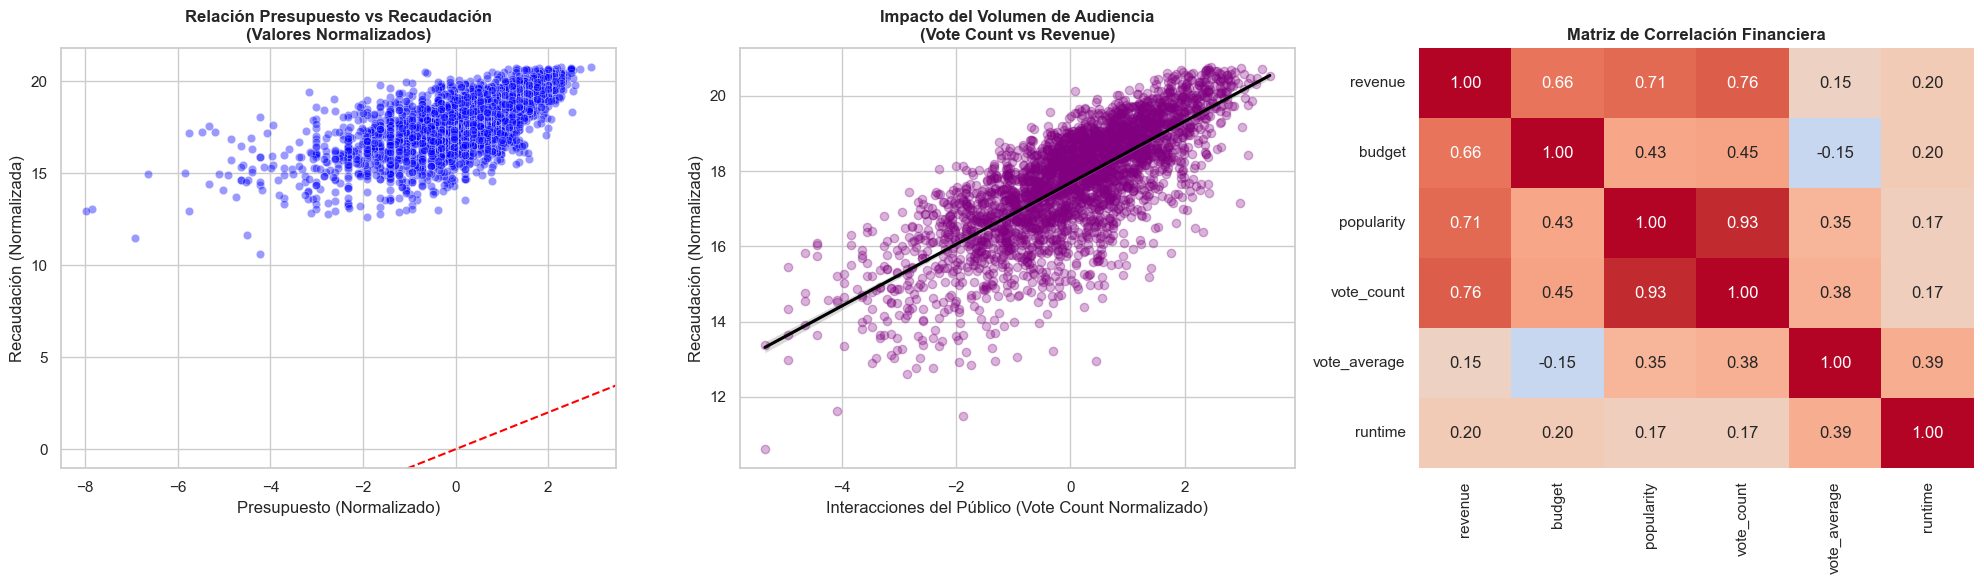

In [33]:


# Configuración de estilo visual para la consultora
sns.set_theme(style="whitegrid", palette="muted")

# Creamos una figura con 3 subgráficos (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -------------------------------------------------------------------------
# 1. Distribución de Ingresos (Revenue) vs Presupuesto (Budget)
# -------------------------------------------------------------------------
sns.scatterplot(
    data=df_limpio, 
    x="budget", 
    y="revenue", 
    alpha=0.4, 
    color="blue",
    ax=axes[0]
)
axes[0].set_title('Relación Presupuesto vs Recaudación\n(Valores Normalizados)', fontweight='bold')
axes[0].set_xlabel('Presupuesto (Normalizado)')
axes[0].set_ylabel('Recaudación (Normalizada)')
axes[0].axline((0, 0), slope=1, color="red", linestyle="--") # Línea de equilibrio de inversión

# -------------------------------------------------------------------------
# 2. El Efecto del "Hype": Interacciones vs Recaudación
# -------------------------------------------------------------------------
sns.regplot(
    data=df_limpio, 
    x="vote_count", 
    y="revenue",
    scatter_kws={'alpha':0.3, 'color':'purple'},
    line_kws={'color': 'black'},
    ax=axes[1]
)
axes[1].set_title('Impacto del Volumen de Audiencia\n(Vote Count vs Revenue)', fontweight='bold')
axes[1].set_xlabel('Interacciones del Público (Vote Count Normalizado)')
axes[1].set_ylabel('Recaudación (Normalizada)')

# -------------------------------------------------------------------------
# 3. Matriz de Correlación de Variables Financieras Clave
# -------------------------------------------------------------------------
# Seleccionamos solo las métricas cuantitativas clave
vars_financieras = ['revenue', 'budget', 'popularity', 'vote_count', 'vote_average', 'runtime']
corr_matrix = df_limpio[vars_financieras].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    vmin=-1, vmax=1, 
    cbar=False,
    ax=axes[2]
)
axes[2].set_title('Matriz de Correlación Financiera', fontweight='bold')

plt.tight_layout()
plt.show()